# 09 — Teste de Gaps de Sequência e Janelas Temporais

## Objetivo

Avaliar se falsos positivos e falsos negativos do baseline são sensíveis à definição temporal:

1. gap usado para separar sequências do mesmo `TAG + Id_Alarme`;
2. tamanho da janela de observação;
3. tamanho do horizonte de previsão.

## Decisão metodológica

Este notebook pausa o refinamento manual de famílias. A razão é que a cadência dos alarmes é
heterogênea e o gap de 60 segundos ainda é uma premissa inicial. Antes de refinar taxonomia, precisamos
entender se a própria construção temporal do episódio e da amostra está gerando parte dos FP/FN.

## Limites

- O target continua sendo episódio futuro da flag `Is_Dont_Go`, não falha confirmada.
- A limpeza analítica permanece congelada.
- Os resultados são exploratórios para escolha de próxima configuração temporal.
- A seleção de threshold é feita apenas na validação.

In [1]:
from pathlib import Path
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

TOP_ALARM_IDS = 200
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

GAP_CANDIDATES_SECONDS = [30, 60, 120, 300, 900, 3600]
WINDOW_CANDIDATES = [
    (4, 4),
    (8, 8),
    (12, 8),
    (24, 8),
    (24, 24),
]

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")
print(f"Gaps avaliados: {GAP_CANDIDATES_SECONDS}")
print(f"Janelas avaliadas: {WINDOW_CANDIDATES}")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Gaps avaliados: [30, 60, 120, 300, 900, 3600]
Janelas avaliadas: [(4, 4), (8, 8), (12, 8), (24, 8), (24, 24)]


## 1. Camada analítica congelada

Repete a limpeza aprovada:

- expurgo apenas do loop localizado da `PE3798`;
- deduplicação exata ignorando somente `Id_Eventos_Telemetria`;
- preservação dos dados brutos.

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tempo_s
0,35608094,265564.0,19941.0,15.2


## 2. Funções de experimento

In [3]:
def build_sequences(gap_seconds):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                            > {gap_seconds * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def build_samples(observation_hours, horizon_hours):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{observation_hours} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{horizon_hours} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{observation_hours} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{horizon_hours} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{observation_hours} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                count(s.inicio) AS sequencias_total,
                count(DISTINCT s.Id_Alarme) AS alarmes_distintos,
                coalesce(sum(s.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(s.registros_brutos_representados), 0) AS registros_brutos_representados,
                coalesce(avg(s.duracao_ms), 0) AS duracao_media_ms,
                coalesce(max(s.duracao_ms), 0) AS duracao_max_ms,
                coalesce(max(s.registros_analiticos), 0) AS maior_sequencia_registros,
                coalesce(sum(s.possui_critico), 0) AS sequencias_com_critico,
                coalesce(sum(s.possui_activate), 0) AS sequencias_com_activate,
                coalesce(sum(s.possui_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(s.possui_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN alarm_sequences s
              ON s.TAG = g.TAG
             AND s.inicio >= g.feature_start
             AND s.inicio < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(s.is_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN alarm_sequences s
              ON s.TAG = g.TAG
             AND s.inicio >= g.prediction_time
             AND s.inicio < g.target_end
            GROUP BY 1
        )
        SELECT
            g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()

    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")

    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()
    return samples

def add_alarm_features(samples):
    top_alarm_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )
    alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
    if not alarm_ids:
        return samples, []

    alarm_columns = ",\n".join(
        f"sum(CASE WHEN s.Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in alarm_ids
    )
    alarm_features = query(
        f'''
        SELECT g.TAG, g.feature_start,
               {alarm_columns}
        FROM sample_grid g
        LEFT JOIN alarm_sequences s
          ON s.TAG = g.TAG
         AND s.inicio >= g.feature_start
         AND s.inicio < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    samples = samples.merge(alarm_features, how="left", on=["TAG", "feature_start"])
    alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
    samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")
    return samples, alarm_feature_names

def prepare_model_matrix(samples, alarm_feature_names):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()

    base_feature_columns = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]
    return samples, base_feature_columns + alarm_feature_names

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(best["threshold"])

def metric_row(experiment, split, y_true, probability, threshold, extra):
    pred = (probability >= threshold).astype(int)
    row = {
        "experimento": experiment,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }
    row.update(extra)
    return row

def fit_evaluate(samples, feature_columns, experiment, extra):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]

    X_train = train[feature_columns].astype("float32")
    y_train = train["target"].astype("int8")
    X_val = val[feature_columns].astype("float32")
    y_val = val["target"].astype("int8")
    X_test = test[feature_columns].astype("float32")
    y_test = test["target"].astype("int8")

    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold = select_threshold(y_val, val_prob)
    test_prob = model.predict_proba(X_test)[:, 1]

    rows = [
        metric_row(experiment, "validacao", y_val, val_prob, threshold, extra),
        metric_row(experiment, "teste", y_test, test_prob, threshold, extra),
    ]
    return pd.DataFrame(rows)

def run_experiment(gap_seconds, observation_hours, horizon_hours, experiment):
    seq_audit = build_sequences(gap_seconds)
    samples = build_samples(observation_hours, horizon_hours)
    samples, alarm_feature_names = add_alarm_features(samples)
    samples, feature_columns = prepare_model_matrix(samples, alarm_feature_names)
    split_audit = (
        samples.groupby(["split", "Tipo"], dropna=False)
        .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
        .reset_index()
    )
    metrics = fit_evaluate(
        samples,
        feature_columns,
        experiment,
        {
            "gap_s": gap_seconds,
            "observacao_h": observation_hours,
            "horizonte_h": horizon_hours,
            "sequencias": int(seq_audit.loc[0, "sequencias"]),
            "sequencias_dont_go": int(seq_audit.loc[0, "sequencias_dont_go"]),
            "features": len(feature_columns),
        },
    )
    return metrics, seq_audit, split_audit

## 3. Teste de gaps

Mantém observação/horizonte em 8h/8h e varia apenas o limite de separação das sequências.

In [4]:
gap_metrics = []
gap_audits = []
gap_split_audits = []

for gap in GAP_CANDIDATES_SECONDS:
    print(f"Executando gap={gap}s, janela 8h/8h")
    start = time.time()
    metrics, seq_audit, split_audit = run_experiment(gap, 8, 8, f"gap_{gap}s_8h_8h")
    metrics["tempo_s"] = round(time.time() - start, 1)
    seq_audit["gap_s"] = gap
    split_audit["gap_s"] = gap
    gap_metrics.append(metrics)
    gap_audits.append(seq_audit)
    gap_split_audits.append(split_audit)

gap_metrics = pd.concat(gap_metrics, ignore_index=True)
gap_audits = pd.concat(gap_audits, ignore_index=True)
gap_split_audits = pd.concat(gap_split_audits, ignore_index=True)

display(gap_audits)
display(gap_split_audits)
display(gap_metrics.sort_values(["split", "f2"], ascending=[True, False]))

Executando gap=30s, janela 8h/8h
Executando gap=60s, janela 8h/8h
Executando gap=120s, janela 8h/8h
Executando gap=300s, janela 8h/8h
Executando gap=900s, janela 8h/8h
Executando gap=3600s, janela 8h/8h


,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia,gap_s
0,8712278,16845.0,4.087116,17533,30
1,4303625,14612.0,8.273977,20604,60
2,3154960,12290.0,11.286385,20604,120
3,2519198,9847.0,14.134694,32607,300
4,979994,7572.0,36.335012,32721,900
5,422227,4689.0,84.334005,140782,3600


,split,Tipo,amostras,positivas,prevalencia,gap_s
0,teste,Caminhao,2670,288,0.107865,30
1,teste,Escavadeira,445,2,0.004494,30
2,treino,Caminhao,10770,1907,0.177066,30
3,treino,Escavadeira,1795,16,0.008914,30
4,validacao,Caminhao,2700,281,0.104074,30
5,validacao,Escavadeira,450,7,0.015556,30
6,teste,Caminhao,2670,288,0.107865,60
7,teste,Escavadeira,445,2,0.004494,60
8,treino,Caminhao,10770,1906,0.176973,60
9,treino,Escavadeira,1795,16,0.008914,60


,experimento,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,observacao_h,horizonte_h,sequencias,sequencias_dont_go,features,tempo_s
1,gap_30s_8h_8h,teste,0.180,3115,290,0.324616,0.801955,0.196721,0.827586,0.317881,0.504202,0.740342,1220,240,980,50,1845,30,8,8,8712278,16845,216,94.4
9,gap_900s_8h_8h,teste,0.205,3115,289,0.343012,0.805266,0.215064,0.750865,0.334361,0.501155,0.735305,1009,217,792,72,2034,900,8,8,979994,7572,216,74.0
7,gap_300s_8h_8h,teste,0.180,3115,290,0.334465,0.807641,0.192090,0.820690,0.311315,0.496040,0.733177,1239,238,1001,52,1824,300,8,8,2519198,9847,216,77.5
5,gap_120s_8h_8h,teste,0.205,3115,290,0.343172,0.809642,0.209662,0.748276,0.327547,0.494305,0.729359,1035,217,818,73,2007,120,8,8,3154960,12290,216,78.5
3,gap_60s_8h_8h,teste,0.205,3115,290,0.327792,0.807241,0.209913,0.744828,0.327521,0.493376,0.728520,1029,216,813,74,2012,60,8,8,4303625,14612,216,88.4
11,gap_3600s_8h_8h,teste,0.205,3115,276,0.271732,0.792167,0.179444,0.771739,0.291183,0.464863,0.714330,1187,213,974,63,1865,3600,8,8,422227,4689,216,71.9
8,gap_900s_8h_8h,validacao,0.205,3150,287,0.331547,0.788972,0.205645,0.710801,0.318999,0.476636,0.717783,992,204,788,83,2075,900,8,8,979994,7572,216,74.0
0,gap_30s_8h_8h,validacao,0.180,3150,288,0.333821,0.787714,0.189819,0.763889,0.304077,0.475984,0.717898,1159,220,939,68,1923,30,8,8,8712278,16845,216,94.4
4,gap_120s_8h_8h,validacao,0.205,3150,288,0.324464,0.787823,0.208247,0.701389,0.321145,0.475966,0.716523,970,202,768,86,2094,120,8,8,3154960,12290,216,78.5
2,gap_60s_8h_8h,validacao,0.205,3150,288,0.337948,0.787369,0.206646,0.690972,0.318145,0.470449,0.712013,963,199,764,89,2098,60,8,8,4303625,14612,216,88.4


,gap_s,threshold,sequencias,sequencias_dont_go,positivas,pr_auc,precision,recall,f2,TP,FP,FN,TN,tempo_s
1,30,0.180,8712278,16845,290,0.324616,0.196721,0.827586,0.504202,240,980,50,1845,94.4
9,900,0.205,979994,7572,289,0.343012,0.215064,0.750865,0.501155,217,792,72,2034,74.0
7,300,0.180,2519198,9847,290,0.334465,0.192090,0.820690,0.496040,238,1001,52,1824,77.5
5,120,0.205,3154960,12290,290,0.343172,0.209662,0.748276,0.494305,217,818,73,2007,78.5
3,60,0.205,4303625,14612,290,0.327792,0.209913,0.744828,0.493376,216,813,74,2012,88.4
11,3600,0.205,422227,4689,276,0.271732,0.179444,0.771739,0.464863,213,974,63,1865,71.9


Melhor gap por F2/precisão na validação: 900s


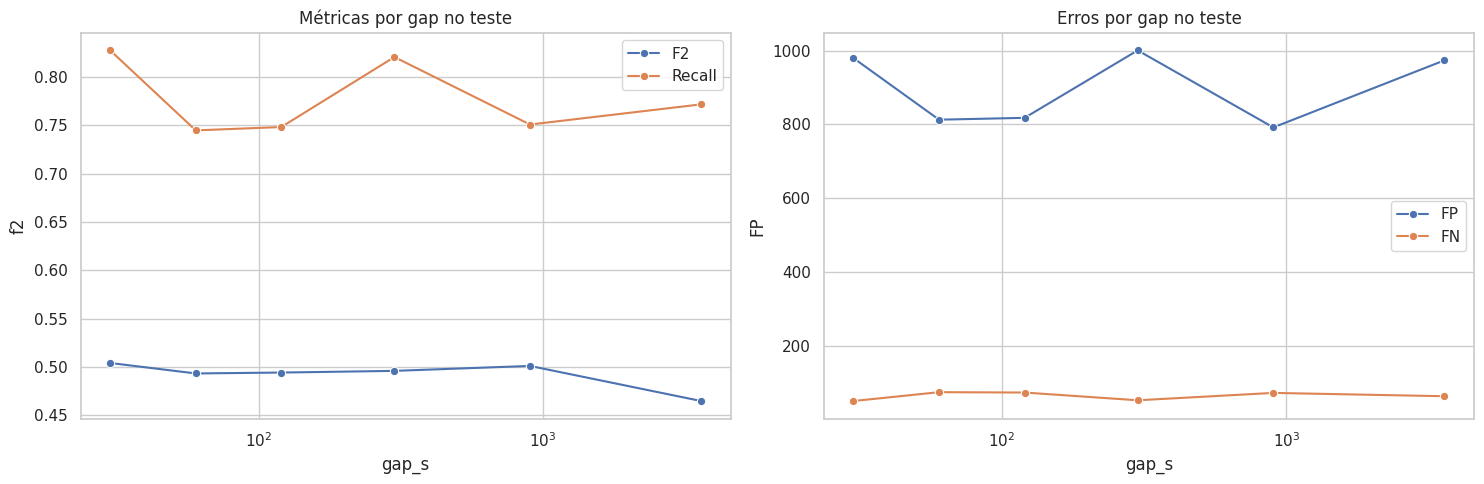

In [5]:
gap_test = gap_metrics[gap_metrics["split"] == "teste"].copy()
display(
    gap_test[[
        "gap_s", "threshold", "sequencias", "sequencias_dont_go", "positivas",
        "pr_auc", "precision", "recall", "f2", "TP", "FP", "FN", "TN", "tempo_s"
    ]].sort_values("f2", ascending=False)
)

best_gap_by_validation = (
    gap_metrics[gap_metrics["split"] == "validacao"]
    .sort_values(["f2", "precision"], ascending=[False, False])
    .iloc[0]["gap_s"]
)
best_gap_by_validation = int(best_gap_by_validation)
print(f"Melhor gap por F2/precisão na validação: {best_gap_by_validation}s")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=gap_test, x="gap_s", y="f2", marker="o", ax=axes[0], label="F2")
sns.lineplot(data=gap_test, x="gap_s", y="recall", marker="o", ax=axes[0], label="Recall")
axes[0].set(title="Métricas por gap no teste", xscale="log")
sns.lineplot(data=gap_test, x="gap_s", y="FP", marker="o", ax=axes[1], label="FP")
sns.lineplot(data=gap_test, x="gap_s", y="FN", marker="o", ax=axes[1], label="FN")
axes[1].set(title="Erros por gap no teste", xscale="log")
plt.tight_layout()
plt.show()

## 4. Teste de janelas

Usa o melhor gap escolhido na validação e varia observação/horizonte. A escolha pelo melhor gap na
validação preserva o teste como avaliação final da configuração escolhida.

In [6]:
window_metrics = []
window_audits = []
window_split_audits = []

for observation_h, horizon_h in WINDOW_CANDIDATES:
    print(f"Executando gap={best_gap_by_validation}s, janela {observation_h}h/{horizon_h}h")
    start = time.time()
    metrics, seq_audit, split_audit = run_experiment(
        best_gap_by_validation,
        observation_h,
        horizon_h,
        f"gap_{best_gap_by_validation}s_{observation_h}h_{horizon_h}h",
    )
    metrics["tempo_s"] = round(time.time() - start, 1)
    seq_audit["observacao_h"] = observation_h
    seq_audit["horizonte_h"] = horizon_h
    split_audit["observacao_h"] = observation_h
    split_audit["horizonte_h"] = horizon_h
    window_metrics.append(metrics)
    window_audits.append(seq_audit)
    window_split_audits.append(split_audit)

window_metrics = pd.concat(window_metrics, ignore_index=True)
window_audits = pd.concat(window_audits, ignore_index=True)
window_split_audits = pd.concat(window_split_audits, ignore_index=True)

display(window_split_audits)
display(window_metrics.sort_values(["split", "f2"], ascending=[True, False]))

Executando gap=900s, janela 4h/4h
Executando gap=900s, janela 8h/8h
Executando gap=900s, janela 12h/8h
Executando gap=900s, janela 24h/8h
Executando gap=900s, janela 24h/24h


,split,Tipo,amostras,positivas,prevalencia,observacao_h,horizonte_h
0,teste,Caminhao,2700,191,0.070741,4,4
1,teste,Escavadeira,450,2,0.004444,4,4
2,treino,Caminhao,10800,1272,0.117778,4,4
3,treino,Escavadeira,1800,10,0.005556,4,4
4,validacao,Caminhao,2700,175,0.064815,4,4
5,validacao,Escavadeira,450,5,0.011111,4,4
6,teste,Caminhao,2670,287,0.107491,8,8
7,teste,Escavadeira,445,2,0.004494,8,8
8,treino,Caminhao,10770,1904,0.176787,8,8
9,treino,Escavadeira,1795,15,0.008357,8,8


,experimento,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,observacao_h,horizonte_h,sequencias,sequencias_dont_go,features,tempo_s
9,gap_900s_24h_24h,teste,0.215,2975,571,0.508615,0.815790,0.305983,0.940455,0.461737,0.664769,0.716900,1755,537,1218,34,1186,900,24,24,979994,7572,216,74.5
7,gap_900s_24h_8h,teste,0.180,3045,285,0.347722,0.820763,0.204545,0.821053,0.327502,0.512259,0.745671,1144,234,910,51,1850,900,24,8,979994,7572,216,74.8
3,gap_900s_8h_8h,teste,0.205,3115,289,0.343012,0.805266,0.215064,0.750865,0.334361,0.501155,0.735305,1009,217,792,72,2034,900,8,8,979994,7572,216,73.2
5,gap_900s_12h_8h,teste,0.165,3080,291,0.328607,0.809968,0.192982,0.831615,0.313269,0.500414,0.734381,1254,242,1012,49,1777,900,12,8,979994,7572,216,73.4
1,gap_900s_4h_4h,teste,0.285,3150,193,0.327206,0.810139,0.241895,0.502591,0.326599,0.413470,0.699892,401,97,304,96,2653,900,4,4,979994,7572,216,72.9
8,gap_900s_24h_24h,validacao,0.215,3080,627,0.485873,0.791661,0.317033,0.920255,0.471598,0.666590,0.706764,1820,577,1243,50,1210,900,24,24,979994,7572,216,74.5
4,gap_900s_12h_8h,validacao,0.165,3115,292,0.287526,0.787244,0.189474,0.801370,0.306483,0.486891,0.723391,1235,234,1001,58,1822,900,12,8,979994,7572,216,73.4
2,gap_900s_8h_8h,validacao,0.205,3150,287,0.331547,0.788972,0.205645,0.710801,0.318999,0.476636,0.717783,992,204,788,83,2075,900,8,8,979994,7572,216,73.2
6,gap_900s_24h_8h,validacao,0.180,3150,287,0.286537,0.789789,0.193578,0.735192,0.306463,0.471403,0.714086,1090,211,879,76,1984,900,24,8,979994,7572,216,74.8
0,gap_900s_4h_4h,validacao,0.285,3150,180,0.295722,0.793790,0.239130,0.488889,0.321168,0.404412,0.697306,368,88,280,92,2690,900,4,4,979994,7572,216,72.9


,observacao_h,horizonte_h,threshold,positivas,pr_auc,precision,recall,f2,TP,FP,FN,TN,tempo_s
9,24,24,0.215,571,0.508615,0.305983,0.940455,0.664769,537,1218,34,1186,74.5
7,24,8,0.180,285,0.347722,0.204545,0.821053,0.512259,234,910,51,1850,74.8
3,8,8,0.205,289,0.343012,0.215064,0.750865,0.501155,217,792,72,2034,73.2
5,12,8,0.165,291,0.328607,0.192982,0.831615,0.500414,242,1012,49,1777,73.4
1,4,4,0.285,193,0.327206,0.241895,0.502591,0.413470,97,304,96,2653,72.9


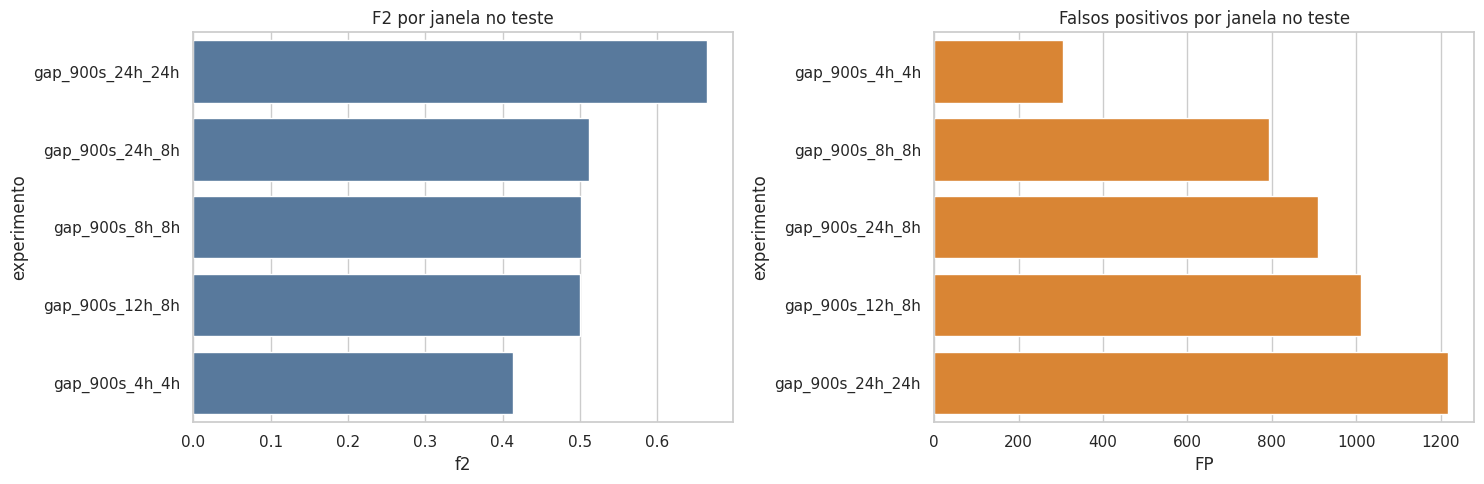

In [7]:
window_test = window_metrics[window_metrics["split"] == "teste"].copy()
display(
    window_test[[
        "observacao_h", "horizonte_h", "threshold", "positivas",
        "pr_auc", "precision", "recall", "f2", "TP", "FP", "FN", "TN", "tempo_s"
    ]].sort_values("f2", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=window_test.sort_values("f2", ascending=False), x="f2", y="experimento", ax=axes[0], color="#4C78A8")
axes[0].set(title="F2 por janela no teste")
sns.barplot(data=window_test.sort_values("FP", ascending=True), x="FP", y="experimento", ax=axes[1], color="#F58518")
axes[1].set(title="Falsos positivos por janela no teste")
plt.tight_layout()
plt.show()

## 5. Leitura auditada

Critérios de decisão:

- se gaps maiores reduzem FP sem explodir FN, o agrupamento de 60s pode estar fragmentando demais;
- se gaps maiores reduzem recall, o agrupamento pode estar juntando eventos independentes demais;
- se janelas longas melhoram recall, o modelo precisa de histórico mais amplo;
- se horizontes longos aumentam prevalência e FP, o target fica mais amplo e menos acionável;
- a próxima etapa deve reavaliar conceitos textuais e famílias manuais apenas nas configurações
  temporais mais promissoras.